In [ ]:
!pip install pyarrow

In [9]:
import pandas as pd
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("gold_table_analysis") \
    .master("local[*]") \
    .getOrCreate()

In [3]:
# import os
# print(os.path.abspath("../../datamart/gold"))
# print(os.path.exists("../../datamart/gold/feature_store"))
# print(os.path.exists("../../datamart/gold/label_store"))

c:\Users\Jesseline\.ssh\MLE_Assignment_2\datamart\gold
True
True


In [ ]:
# feature_df = spark.read.parquet("../../datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet")
# label_df = spark.read.parquet("../../datamart/gold/label_store/gold_risk_performance_2023_01_01.parquet")

In [10]:
feature_df = spark.read.parquet("../datamart/gold/feature_store/*.parquet")
label_df = spark.read.parquet("../datamart/gold/label_store/*.parquet")

feature_df.show(5)
label_df.show(5)

+-----------+-------------+---+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------------+------------------------+------------------+-------------------+-----------------------+---------------+--------------+--------------------+--------------------+--------------------+-----------------------+------------------+------------+--------------+---------------------+-------------------------+---------------+-------------+------+-----+-----+-----+-----+-----+-----+-----+------+-----+-----+-----+-----+-----+------+-----+------+-----+-----+-----+
|Customer_ID|snapshot_date|Age|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Outstanding_Debt|Credit_Utilization_Ratio|Credit_History_Age|

## EDA feature store

In [12]:
# using spark to read the parquet file and convert to pandas dataframe
type(feature_df)

feature_df.toPandas()

,Customer_ID,snapshot_date,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,cus_0x1037,2023-01-01,45.0,15989.085,1086.424,5.0,4.0,2.0,4.0,"[credit-builder loan, auto loan, mortgage loan]",...,164.0,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0
1,cus_0x1069,2023-01-01,32.0,58637.340,4799.445,4.0,6.0,10.0,NaN,"[personal loan, auto loan]",...,203.0,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0
2,cus_0x114a,2023-01-01,43.0,15305.460,1230.455,0.0,7.0,2.0,2.0,"[student loan, home equity loan]",...,14.0,203.0,26.0,86.0,171.0,125.0,-130.0,257.0,17.0,262.0
3,cus_0x1184,2023-01-01,49.0,19867.475,1396.623,3.0,5.0,11.0,3.0,"[student loan, mortgage loan, payday loan]",...,6.0,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0
4,cus_0x1297,2023-01-01,46.0,57738.060,4881.505,9.0,8.0,30.0,9.0,"[payday loan, personal loan, mortgage loan, ho...",...,34.0,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11969,cus_0xd50,2024-10-01,41.0,43771.850,3600.654,4.0,3.0,9.0,1.0,[student loan],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11970,cus_0xde4,2024-10-01,30.0,75402.520,6221.543,2.0,4.0,3.0,3.0,"[auto loan, mortgage loan]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11971,cus_0xe16,2024-10-01,18.0,37976.680,2997.723,9.0,9.0,18.0,7.0,"[auto loan, personal loan, student loan, credi...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11972,cus_0xe7a,2024-10-01,32.0,7711.970,395.664,10.0,5.0,29.0,7.0,"[debt consolidation loan, home equity loan, pe...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# using spark to read the parquet file and convert to pandas dataframe
feature_pd = feature_df.toPandas()

feature_pd.info()
feature_pd.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11974 entries, 0 to 11973
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                11974 non-null  object 
 1   snapshot_date              11974 non-null  object 
 2   Age                        11670 non-null  float64
 3   Annual_Income              11974 non-null  float64
 4   Monthly_Inhand_Salary      11974 non-null  float64
 5   Num_Bank_Accounts          11809 non-null  float64
 6   Num_Credit_Card            11690 non-null  float64
 7   Interest_Rate              11714 non-null  float64
 8   Num_of_Loan                11423 non-null  float64
 9   Type_of_Loan               10606 non-null  object 
 10  Delay_from_due_date        11974 non-null  int32  
 11  Num_of_Delayed_Payment     11974 non-null  float64
 12  Changed_Credit_Limit       11728 non-null  float64
 13  Num_Credit_Inquiries       11790 non-null  flo

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
count,11670.000000,1.197400e+04,11974.000000,11809.000000,11690.000000,11714.000000,11423.000000,11974.000000,11974.000000,11728.000000,...,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000
mean,33.639332,1.644985e+05,4194.017735,5.358286,5.541061,14.548489,3.522630,21.051695,33.492233,10.417717,...,97.857143,97.526855,99.253844,96.200357,97.300423,96.733006,98.126588,100.107533,96.299086,95.520169
std,10.757675,1.313451e+06,3187.070399,2.596855,2.073068,8.753894,2.441684,14.884603,242.133785,6.803699,...,94.541763,95.408710,95.855150,95.908361,96.012450,95.850936,96.086552,96.592990,97.574093,99.604000
min,14.000000,7.005930e+03,303.645000,0.000000,0.000000,1.000000,0.000000,-5.000000,-3.000000,-6.490000,...,-298.000000,-289.000000,-248.000000,-293.000000,-271.000000,-277.000000,-309.000000,-299.000000,-278.000000,-313.000000
25%,25.000000,1.943758e+04,1623.436500,3.000000,4.000000,7.000000,2.000000,10.000000,9.000000,5.400000,...,34.000000,33.000000,34.000000,33.000000,33.000000,30.000000,33.000000,33.000000,30.000000,27.000000
50%,33.000000,3.759240e+04,3088.674500,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.420000,...,100.000000,101.000000,103.000000,100.000000,100.000000,99.000000,101.000000,104.000000,99.000000,98.500000
75%,42.000000,7.289361e+04,5967.644250,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.960000,...,167.000000,168.750000,170.000000,165.750000,168.000000,168.000000,168.000000,174.000000,168.000000,168.000000
max,56.000000,2.383470e+07,15204.633000,11.000000,11.000000,34.000000,9.000000,67.000000,4293.000000,36.970000,...,259.000000,261.000000,263.000000,262.000000,260.000000,262.000000,262.000000,262.000000,264.000000,265.000000


In [15]:
# if using spark
missing_feature = feature_pd.isnull().sum()
missing_feature

Customer_ID                     0
snapshot_date                   0
Age                           304
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts             165
Num_Credit_Card               284
Interest_Rate                 260
Num_of_Loan                   551
Type_of_Loan                 1368
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit          246
Num_Credit_Inquiries          184
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age              0
Total_EMI_per_month             0
Amount_invested_monthly         0
Monthly_Balance                 0
num_loan_types                  0
debt_to_income                  0
emi_to_salary                   0
investment_rate                 0
has_credit_limit_change       246
balance_to_debt                 0
inq_per_loan                  727
Credit_Mix_vec                  0
Payment_Behaviour_vec           0
Payment_of_Min

In [16]:
# add Median age to missing age

print("Missing before:", feature_pd["Age"].isna().sum())

feature_pd["Age"] = feature_pd["Age"].fillna(
    feature_pd["Age"].median()
)

print("Missing after:", feature_pd["Age"].isna().sum())

Missing before: 304
Missing after: 0


In [7]:
# add Median num_bank_accounts to missing num_bank_accounts

print("Missing before:", feature_pd["Num_Bank_Accounts"].isna().sum())

feature_pd["Num_Bank_Accounts"] = feature_pd["Num_Bank_Accounts"].fillna(
    feature_pd["Num_Bank_Accounts"].median()
)

print("Missing after:", feature_pd["Num_Bank_Accounts"].isna().sum())

Missing before: 165
Missing after: 0


In [8]:
# add Median Num_Credit_Card to missing Num_Credit_Card

print("Missing before:", feature_pd["Num_Credit_Card"].isna().sum())

feature_pd["Num_Credit_Card"] = feature_pd["Num_Credit_Card"].fillna(
    feature_pd["Num_Credit_Card"].median()
)

print("Missing after:", feature_pd["Num_Credit_Card"].isna().sum())

Missing before: 284
Missing after: 0


In [9]:
# add Median Interest_Rate to missing Interest_Rate

print("Missing before:", feature_pd["Interest_Rate"].isna().sum())

feature_pd["Interest_Rate"] = feature_pd["Interest_Rate"].fillna(
    feature_pd["Interest_Rate"].median()
)

print("Missing after:", feature_pd["Interest_Rate"].isna().sum())

Missing before: 260
Missing after: 0


In [10]:
# add Median Num_of_Loan to missing Num_of_Loan

print("Missing before:", feature_pd["Num_of_Loan"].isna().sum())

feature_pd["Num_of_Loan"] = feature_pd["Num_of_Loan"].fillna(
    feature_pd["Num_of_Loan"].median()
)

print("Missing after:", feature_pd["Num_of_Loan"].isna().sum())

Missing before: 551
Missing after: 0


In [11]:
# add Median Changed_Credit_Limit to missing Changed_Credit_Limit

print("Missing before:", feature_pd["Changed_Credit_Limit"].isna().sum())

feature_pd["Changed_Credit_Limit"] = feature_pd["Changed_Credit_Limit"].fillna(
    feature_pd["Changed_Credit_Limit"].median()
)

print("Missing after:", feature_pd["Changed_Credit_Limit"].isna().sum())

Missing before: 246
Missing after: 0


In [12]:
# add Median Changed_Credit_LimitNum_Credit_Inquiries
print("Missing before:", feature_pd["Num_Credit_Inquiries"].isna().sum())

feature_pd["Num_Credit_Inquiries"] = feature_pd["Num_Credit_Inquiries"].fillna(
    feature_pd["Num_Credit_Inquiries"].median()
)

print("Missing after:", feature_pd["Num_Credit_Inquiries"].isna().sum())

Missing before: 184
Missing after: 0


In [13]:
# add Median inq_per_loan" to missing inq_per_loan"

print("Missing before:", feature_pd["inq_per_loan"].isna().sum())

feature_pd["inq_per_loan"] = feature_pd["inq_per_loan"].fillna(
    feature_pd["inq_per_loan"].median()
)

print("Missing after:", feature_pd["inq_per_loan"].isna().sum())

Missing before: 727
Missing after: 0


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual_Income'}>,
        <Axes: title={'center': 'Outstanding_Debt'}>,
        <Axes: title={'center': 'Credit_Utilization_Ratio'}>,
        <Axes: title={'center': 'debt_to_income'}>],
       [<Axes: title={'center': 'emi_to_salary'}>,
        <Axes: title={'center': 'Monthly_Inhand_Salary'}>,
        <Axes: title={'center': 'Num_Bank_Accounts'}>,
        <Axes: title={'center': 'Interest_Rate'}>,
        <Axes: title={'center': 'Num_of_Loan'}>],
       [<Axes: title={'center': 'Delay_from_due_date'}>,
        <Axes: title={'center': 'Num_of_Delayed_Payment'}>,
        <Axes: title={'center': 'Changed_Credit_Limit'}>,
        <Axes: title={'center': 'Num_Credit_Inquiries'}>,
        <Axes: title={'center': 'Credit_History_Age'}>],
       [<Axes: title={'center': 'Total_EMI_per_month'}>,
        <Axes: title={'center': 'Amount_invested_monthly'}>,
        <Axes: title={'center': 'Monthly_Balance'}>,
        <Axe

26/06/15 12:52:59 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


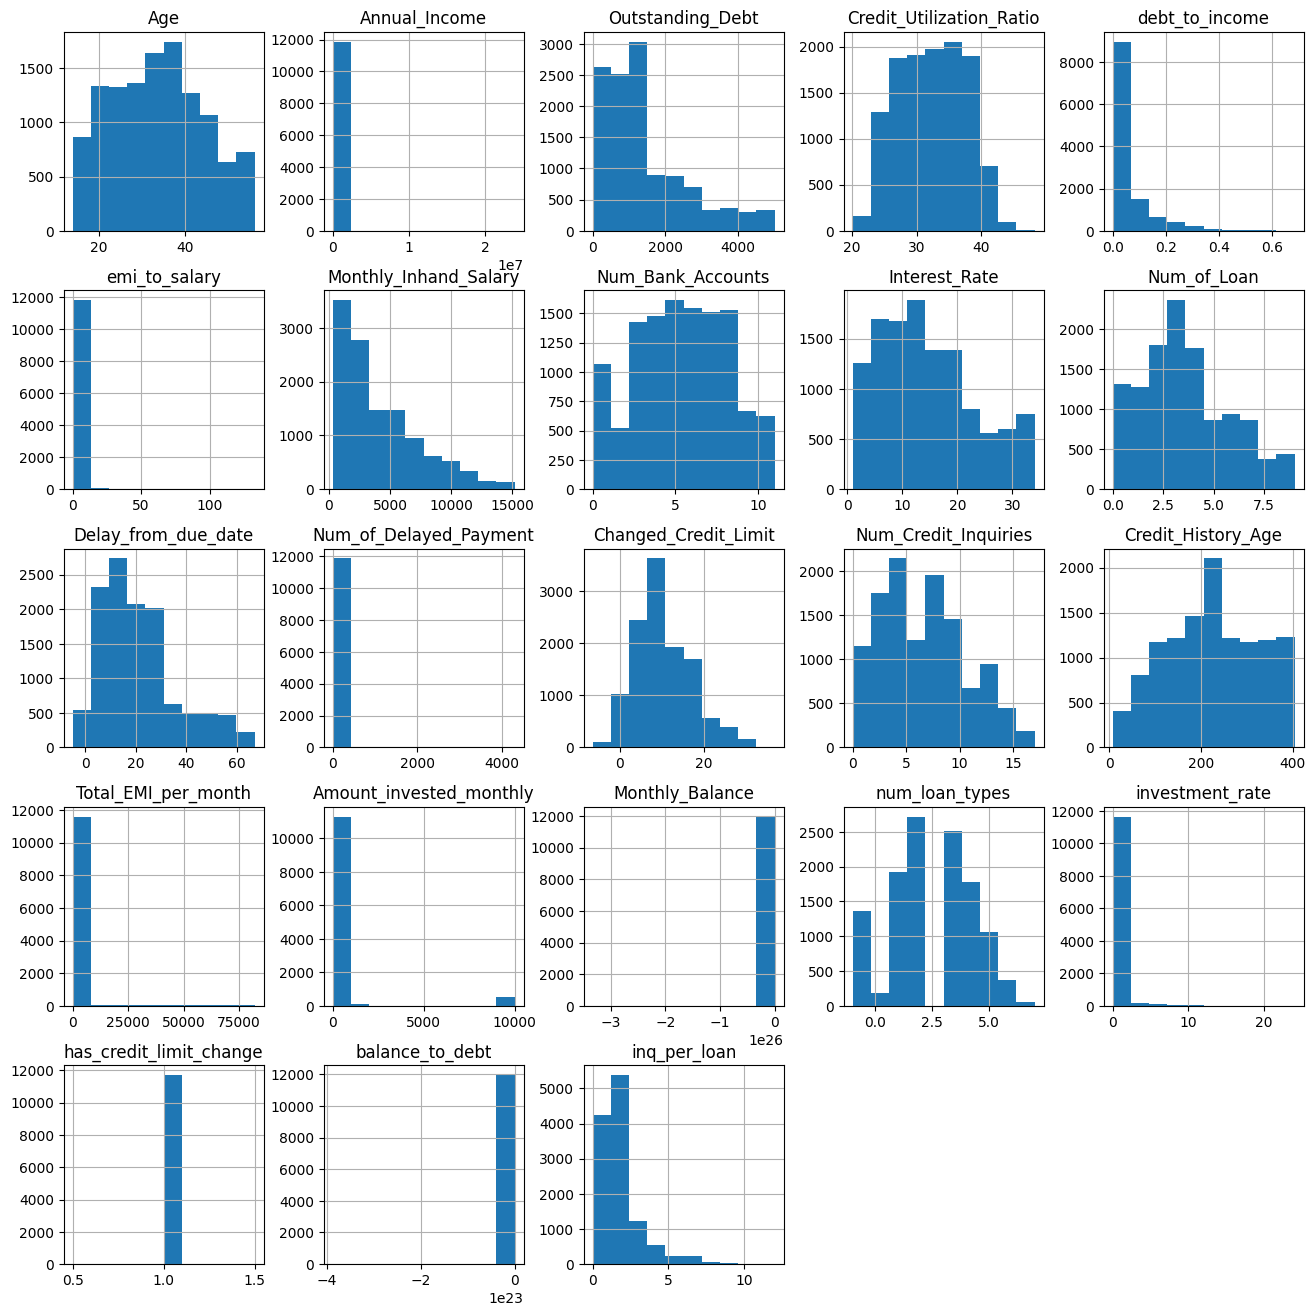

In [14]:
attributes = [
    "Age",
    "Annual_Income",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "debt_to_income",
    "emi_to_salary",

    
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Interest_Rate",
    "Num_of_Loan",
    "Type_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Credit_History_Age",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "num_loan_types",
    "investment_rate",
    "has_credit_limit_change",
    "balance_to_debt",
    "inq_per_loan",
    "Credit_Mix_vec",
    "Payment_Behaviour_vec",
    "Payment_of_Min_Amount_vec",
    "Occupation_vec",
    "age_group_vec"

]

feature_pd[attributes].hist(figsize=(16,16))

In [15]:
corr_features = feature_pd.corr(numeric_only=True)
corr_features 

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
Age,1.000000,0.023243,0.088996,-0.183369,-0.140767,-0.212942,-0.204529,-0.168633,-0.000899,-0.157529,...,0.011924,-0.002026,-0.009755,0.000673,0.024140,-0.014469,-0.021990,-0.004063,-0.003003,0.011124
Annual_Income,0.023243,1.000000,0.025089,-0.011491,-0.005815,-0.014151,-0.013480,-0.015334,0.001791,-0.008635,...,0.013637,0.012108,0.025614,-0.011403,0.003301,-0.007902,0.011316,-0.011175,-0.005750,-0.022497
Monthly_Inhand_Salary,0.088996,0.025089,1.000000,-0.282707,-0.212862,-0.297320,-0.250267,-0.250345,0.003883,-0.176976,...,0.002774,0.001227,-0.007657,-0.007251,0.000646,0.002064,0.000805,0.004500,0.002942,-0.010141
Num_Bank_Accounts,-0.183369,-0.011491,-0.282707,1.000000,0.434003,0.576503,0.458173,0.555814,0.015406,0.334017,...,-0.022519,0.000649,-0.003374,0.003922,-0.008680,-0.004679,0.022762,-0.001494,-0.003318,-0.001371
Num_Credit_Card,-0.140767,-0.005815,-0.212862,0.434003,1.000000,0.482577,0.405835,0.471266,0.007776,0.252352,...,-0.017847,0.007789,0.020912,-0.004867,0.004628,0.009357,0.009189,-0.008255,-0.008156,0.002415
Interest_Rate,-0.212942,-0.014151,-0.297320,0.576503,0.482577,1.000000,0.541081,0.584628,0.009966,0.361940,...,-0.014974,-0.011038,0.004006,0.001671,-0.007485,-0.004881,0.008141,-0.001337,-0.004000,0.003496
Num_of_Loan,-0.204529,-0.013480,-0.250267,0.458173,0.405835,0.541081,1.000000,0.493096,0.005549,0.362801,...,-0.005293,0.015881,0.002249,-0.003538,0.010582,0.005264,0.001713,0.005885,-0.005812,-0.001427
Delay_from_due_date,-0.168633,-0.015334,-0.250345,0.555814,0.471266,0.584628,0.493096,1.000000,0.004667,0.295141,...,-0.007501,0.009671,0.018795,0.007996,-0.005084,-0.001965,0.011484,0.001452,-0.007966,0.003309
Num_of_Delayed_Payment,-0.000899,0.001791,0.003883,0.015406,0.007776,0.009966,0.005549,0.004667,1.000000,-0.000644,...,0.010790,-0.009159,0.006043,-0.000146,0.006127,0.006105,-0.003181,0.020201,0.002927,0.007075
Changed_Credit_Limit,-0.157529,-0.008635,-0.176976,0.334017,0.252352,0.361940,0.362801,0.295141,-0.000644,1.000000,...,-0.002667,0.007575,-0.000299,0.018862,-0.003189,0.001877,-0.001044,-0.002825,-0.014466,-0.007150


In [16]:
feature_pd[[f"fe_{i}" for i in range(1,21)]].describe().T

,count,mean,std,min,25%,50%,75%,max
fe_1,8974.0,100.397259,95.339776,-307.0,33.00,103.0,171.00,261.0
fe_2,8974.0,100.662358,94.319658,-301.0,37.00,104.0,170.00,262.0
fe_3,8974.0,101.154446,95.688315,-256.0,35.00,103.0,172.00,264.0
fe_4,8974.0,102.801315,95.445781,-292.0,37.00,106.0,173.00,268.0
fe_5,8974.0,104.560508,94.712220,-258.0,38.00,108.0,174.00,267.0
fe_6,8974.0,98.062402,94.639413,-259.0,32.00,100.0,167.00,264.0
fe_7,8974.0,106.550591,94.613534,-240.0,42.00,110.0,176.00,268.0
fe_8,8974.0,107.520615,95.789568,-348.0,42.00,109.0,179.00,272.0
fe_9,8974.0,110.717629,94.736102,-244.0,45.25,113.0,180.00,273.0
fe_10,8974.0,115.092267,95.858119,-264.0,49.00,119.0,184.00,280.0


## EDA Label store

In [17]:
type(label_df)

label_df.toPandas()

,loan_id,Customer_ID,label,snapshot_date
0,cus_0x1037_2023_01_01,cus_0x1037,0,2023-07-01
1,cus_0x1069_2023_01_01,cus_0x1069,0,2023-07-01
2,cus_0x114a_2023_01_01,cus_0x114a,0,2023-07-01
3,cus_0x1184_2023_01_01,cus_0x1184,0,2023-07-01
4,cus_0x1297_2023_01_01,cus_0x1297,1,2023-07-01
...,...,...,...,...
8969,cus_0xdf6_2023_09_01,cus_0xdf6,0,2024-03-01
8970,cus_0xe23_2023_09_01,cus_0xe23,0,2024-03-01
8971,cus_0xe4e_2023_09_01,cus_0xe4e,0,2024-03-01
8972,cus_0xedd_2023_09_01,cus_0xedd,0,2024-03-01


In [18]:
label_pd = label_df.toPandas()

label_pd.info()
label_pd.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8974 entries, 0 to 8973
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   loan_id        8974 non-null   object
 1   Customer_ID    8974 non-null   object
 2   label          8974 non-null   int32 
 3   snapshot_date  8974 non-null   object
dtypes: int32(1), object(3)
memory usage: 245.5+ KB


,label
count,8974.000000
mean,0.288723
std,0.453194
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [19]:
missing_label = label_pd.isnull().sum()
missing_label

loan_id          0
Customer_ID      0
label            0
snapshot_date    0
dtype: int64

In [20]:
# imbalance

print(label_pd["label"].value_counts())
print(label_pd["label"].value_counts(normalize=True))

label
0    6383
1    2591
Name: count, dtype: int64
label
0    0.711277
1    0.288723
Name: proportion, dtype: float64


## Merge feature & label store

In [ ]:
# merged_tb = feature_pd.merge(
#     label_pd,
#     on=["Customer_ID", "snapshot_date"],
#     how="left"
# )

# merged_tb

In [ ]:
# # create csv file
# merged_tb.to_csv("merged.csv", index=False)

In [ ]:
# print(feature_pd.dtypes)
# print("------------")
# print(label_pd.dtypes)

In [ ]:
# print(feature_pd["snapshot_date"].unique()[:10])
# print(label_pd["snapshot_date"].unique()[:10])

In [21]:
# dates do not align on snapshot date as shown above. 
# To align them by shifting the label snapshot_date back by 6 months before merging

from dateutil.relativedelta import relativedelta

label_pd["feature_snapshot_date"] = label_pd["snapshot_date"].apply(
    lambda x: x - relativedelta(months=6)
)

label_pd_1 = (
    label_pd
    .groupby(["Customer_ID", "feature_snapshot_date"], as_index=False)
    .agg(label=("label", "max"))
    .rename(columns={"feature_snapshot_date": "snapshot_date"})
)

In [22]:
merged_tb = feature_pd.merge(
    label_pd_1,
    on=["Customer_ID", "snapshot_date"],
    how="inner"
)

merged_tb 

,Customer_ID,snapshot_date,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,label
0,cus_0x1037,2023-01-01,45.0,15989.085,1086.424,5.0,4.0,2.0,4.0,"[credit-builder loan, auto loan, mortgage loan]",...,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0,0
1,cus_0x1069,2023-01-01,32.0,58637.340,4799.445,4.0,6.0,10.0,3.0,"[personal loan, auto loan]",...,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0,0
2,cus_0x114a,2023-01-01,43.0,15305.460,1230.455,0.0,7.0,2.0,2.0,"[student loan, home equity loan]",...,203.0,26.0,86.0,171.0,125.0,-130.0,257.0,17.0,262.0,0
3,cus_0x1184,2023-01-01,49.0,19867.475,1396.623,3.0,5.0,11.0,3.0,"[student loan, mortgage loan, payday loan]",...,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0,0
4,cus_0x1297,2023-01-01,46.0,57738.060,4881.505,9.0,8.0,30.0,9.0,"[payday loan, personal loan, mortgage loan, ho...",...,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,cus_0xdf6,2023-09-01,55.0,40453.850,2772.811,2.0,2.0,1.0,0.0,None,...,257.0,-40.0,142.0,-50.0,178.0,57.0,70.0,17.0,36.0,0
8970,cus_0xe23,2023-09-01,39.0,17815.585,1427.632,8.0,6.0,18.0,1.0,[home equity loan],...,124.0,190.0,-13.0,258.0,25.0,53.0,85.0,80.0,50.0,0
8971,cus_0xe4e,2023-09-01,22.0,108073.680,8738.140,3.0,3.0,9.0,0.0,None,...,83.0,80.0,175.0,100.0,258.0,86.0,24.0,124.0,-31.0,0
8972,cus_0xedd,2023-09-01,33.0,125468.440,10445.703,4.0,4.0,10.0,4.0,"[payday loan, credit-builder loan, personal lo...",...,208.0,140.0,22.0,65.0,143.0,-155.0,61.0,217.0,-37.0,0


In [23]:
important_features = [
    "Outstanding_Debt",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Credit_History_Age",
    "debt_to_income",
    "emi_to_salary",
    "balance_to_debt",

    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    # "Type_of_Loan",
    "Changed_Credit_Limit",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "num_loan_types",
    "investment_rate",
    "has_credit_limit_change",
    "inq_per_loan",

]

for col in important_features:
    print("\n", col)
    print(
        merged_tb.groupby("label")[col].mean()
    )


 Outstanding_Debt
label
0    1199.099416
1    1993.571123
Name: Outstanding_Debt, dtype: float64

 Delay_from_due_date
label
0    17.881404
1    28.756465
Name: Delay_from_due_date, dtype: float64

 Num_of_Delayed_Payment
label
0    34.969920
1    33.419143
Name: Num_of_Delayed_Payment, dtype: float64

 Num_Credit_Inquiries
label
0    5.775184
1    8.625241
Name: Num_Credit_Inquiries, dtype: float64

 Credit_History_Age
label
0    242.746671
1    180.046700
Name: Credit_History_Age, dtype: float64

 debt_to_income
label
0    0.046500
1    0.094613
Name: debt_to_income, dtype: float64

 emi_to_salary
label
0    0.611183
1    0.685990
Name: emi_to_salary, dtype: float64

 balance_to_debt
label
0    1.871265e+00
1   -1.494597e+20
Name: balance_to_debt, dtype: float64

 Age
label
0    34.384615
1    31.944423
Name: Age, dtype: float64

 Annual_Income
label
0    171366.343942
1    138027.013070
Name: Annual_Income, dtype: float64

 Monthly_Inhand_Salary
label
0    4467.946658
1    3423.167

## monthly balance & balance to debt

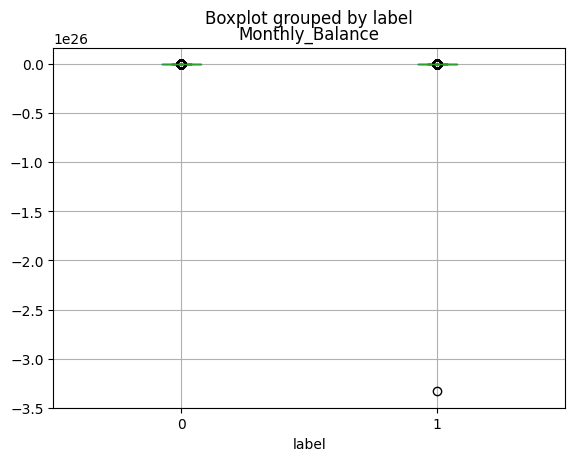

In [24]:
# checking why monthly balance is negative
import matplotlib.pyplot as plt

merged_tb.boxplot(
    column="Monthly_Balance",
    by="label"
)

plt.show()

In [25]:
merged_tb.sort_values("Monthly_Balance").head(20)[
    ["Customer_ID", "snapshot_date", "Monthly_Balance", "label"]
]

,Customer_ID,snapshot_date,Monthly_Balance,label
2685,cus_0x2f7e,2024-04-01,-3.333333e+26,1
2491,cus_0xa7b6,2023-06-01,3.830000e-01,0
478,cus_0xbca6,2023-01-01,7.100000e-01,1
2261,cus_0x5ae1,2023-06-01,1.526000e+00,1
4467,cus_0x8e88,2023-02-01,1.780000e+00,0
6422,cus_0x867a,2023-11-01,3.968000e+00,0
3705,cus_0x307e,2023-03-01,5.958000e+00,1
5078,cus_0xbbb0,2024-06-01,6.612000e+00,1
7126,cus_0x2059,2024-01-01,6.992000e+00,0
8575,cus_0x29e1,2023-09-01,1.088500e+01,1


In [26]:
merged_tb["Monthly_Balance"].describe()

count    8.974000e+03
mean    -3.714434e+22
std      3.518728e+24
min     -3.333333e+26
25%      2.713102e+02
50%      3.388805e+02
75%      4.741807e+02
max      1.460917e+03
Name: Monthly_Balance, dtype: float64

In [27]:
# remove negative outlier


merged_tb = merged_tb[
    merged_tb["Monthly_Balance"] > -1e10
].copy()

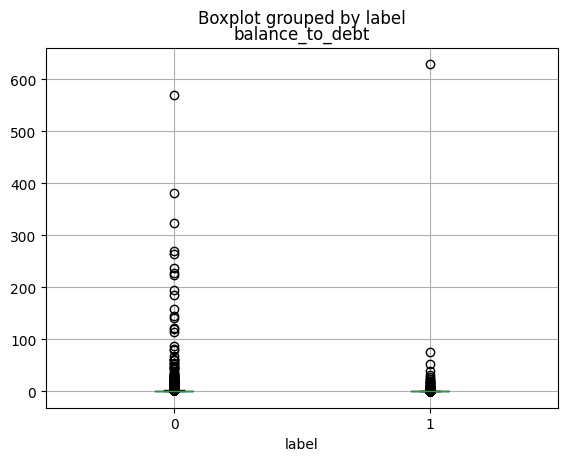

In [28]:
# checking why balance to debt is negative
merged_tb.boxplot(
    column="balance_to_debt",
    by="label"
)

plt.show()

In [29]:
merged_tb.sort_values("balance_to_debt").tail(20)[
    ["Customer_ID", "snapshot_date", "balance_to_debt", "label"]
]

,Customer_ID,snapshot_date,balance_to_debt,label
3352,cus_0x6974,2023-04-01,79.527867,0
1371,cus_0x9046,2024-03-01,80.926282,0
1888,cus_0x86ea,2024-02-01,86.795952,0
3769,cus_0x4813,2023-03-01,114.036146,0
7919,cus_0x9694,2023-08-01,119.314474,0
6811,cus_0x6612,2023-10-01,122.728696,0
4279,cus_0x49c4,2023-02-01,141.233636,0
5724,cus_0x390d,2023-12-01,144.471795,0
8130,cus_0x3442,2023-07-01,158.225207,0
5147,cus_0x1a5c,2024-05-01,185.292308,0


In [30]:
print(merged_tb["balance_to_debt"].describe())

merged_tb["balance_to_debt"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

count    8973.000000
mean        1.571344
std        13.201174
min         0.000532
25%         0.150672
50%         0.339621
75%         0.793227
max       629.570779
Name: balance_to_debt, dtype: float64


0.900      1.992610
0.950      3.741939
0.990     17.263560
0.995     29.759779
0.999    195.667154
Name: balance_to_debt, dtype: float64

In [31]:
cap = merged_tb["balance_to_debt"].quantile(0.99)

merged_tb["balance_to_debt"] = (
    merged_tb["balance_to_debt"]
    .clip(upper=cap)
)

merged_tb

,Customer_ID,snapshot_date,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,label
0,cus_0x1037,2023-01-01,45.0,15989.085,1086.424,5.0,4.0,2.0,4.0,"[credit-builder loan, auto loan, mortgage loan]",...,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0,0
1,cus_0x1069,2023-01-01,32.0,58637.340,4799.445,4.0,6.0,10.0,3.0,"[personal loan, auto loan]",...,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0,0
2,cus_0x114a,2023-01-01,43.0,15305.460,1230.455,0.0,7.0,2.0,2.0,"[student loan, home equity loan]",...,203.0,26.0,86.0,171.0,125.0,-130.0,257.0,17.0,262.0,0
3,cus_0x1184,2023-01-01,49.0,19867.475,1396.623,3.0,5.0,11.0,3.0,"[student loan, mortgage loan, payday loan]",...,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0,0
4,cus_0x1297,2023-01-01,46.0,57738.060,4881.505,9.0,8.0,30.0,9.0,"[payday loan, personal loan, mortgage loan, ho...",...,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,cus_0xdf6,2023-09-01,55.0,40453.850,2772.811,2.0,2.0,1.0,0.0,None,...,257.0,-40.0,142.0,-50.0,178.0,57.0,70.0,17.0,36.0,0
8970,cus_0xe23,2023-09-01,39.0,17815.585,1427.632,8.0,6.0,18.0,1.0,[home equity loan],...,124.0,190.0,-13.0,258.0,25.0,53.0,85.0,80.0,50.0,0
8971,cus_0xe4e,2023-09-01,22.0,108073.680,8738.140,3.0,3.0,9.0,0.0,None,...,83.0,80.0,175.0,100.0,258.0,86.0,24.0,124.0,-31.0,0
8972,cus_0xedd,2023-09-01,33.0,125468.440,10445.703,4.0,4.0,10.0,4.0,"[payday loan, credit-builder loan, personal lo...",...,208.0,140.0,22.0,65.0,143.0,-155.0,61.0,217.0,-37.0,0


In [32]:
print(merged_tb["balance_to_debt"].describe())

count    8973.000000
mean        0.996315
std         2.297472
min         0.000532
25%         0.150672
50%         0.339621
75%         0.793227
max        17.263560
Name: balance_to_debt, dtype: float64


## correlation

In [33]:
corr = merged_tb[
    [
        "Outstanding_Debt",
        "Delay_from_due_date",
        "Num_of_Delayed_Payment",
        "Num_Credit_Inquiries",
        "Credit_History_Age",
        "debt_to_income",
        "emi_to_salary",
        

        "balance_to_debt",
        "Age",
        "Annual_Income",
        "Monthly_Inhand_Salary",
        "Num_Bank_Accounts",
        "Num_Credit_Card",
        "Interest_Rate",
        "Num_of_Loan",
        # "Type_of_Loan",
        "Changed_Credit_Limit",
        "Credit_Utilization_Ratio",
        "Total_EMI_per_month",
        "Amount_invested_monthly",
        "Monthly_Balance",
        "num_loan_types",
        "investment_rate",
        # "has_credit_limit_change",
        "inq_per_loan",

        "label"

    ]
].corr()

corr["label"].sort_values()

Credit_History_Age         -0.285734
Monthly_Inhand_Salary      -0.150248
Monthly_Balance            -0.149790
balance_to_debt            -0.128192
Age                        -0.104024
Credit_Utilization_Ratio   -0.034170
Annual_Income              -0.011624
Total_EMI_per_month        -0.010671
Amount_invested_monthly    -0.010643
Num_of_Delayed_Payment     -0.002784
inq_per_loan               -0.002686
emi_to_salary               0.006798
investment_rate             0.027448
Changed_Credit_Limit        0.055542
num_loan_types              0.246036
debt_to_income              0.247904
Num_Bank_Accounts           0.248879
Num_of_Loan                 0.272511
Num_Credit_Card             0.298222
Outstanding_Debt            0.311705
Num_Credit_Inquiries        0.326506
Delay_from_due_date         0.330603
Interest_Rate               0.351658
label                       1.000000
Name: label, dtype: float64

In [34]:
# remove column as redundant
merged_tb = merged_tb.drop(columns=["has_credit_limit_change"])

print("has_credit_limit_change" in merged_tb.columns)


False


In [35]:
features = [
        "Outstanding_Debt",
        "Delay_from_due_date",
        "Num_of_Delayed_Payment",
        "Num_Credit_Inquiries",
        "Credit_History_Age",
        "debt_to_income",
        "emi_to_salary",
        

        "balance_to_debt",
        "Age",
        "Annual_Income",
        "Monthly_Inhand_Salary",
        "Num_Bank_Accounts",
        "Num_Credit_Card",
        "Interest_Rate",
        "Num_of_Loan",
        # "Type_of_Loan",
        "Changed_Credit_Limit",
        "Credit_Utilization_Ratio",
        "Total_EMI_per_month",
        "Amount_invested_monthly",
        "Monthly_Balance",
        "num_loan_types",
        "investment_rate",
        # "has_credit_limit_change",
        "inq_per_loan",
	]
	
merged_tb[features].corr()

,Outstanding_Debt,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_History_Age,debt_to_income,emi_to_salary,balance_to_debt,Age,Annual_Income,...,Interest_Rate,Num_of_Loan,Changed_Credit_Limit,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,num_loan_types,investment_rate,inq_per_loan
Outstanding_Debt,1.000000,0.567754,0.002217,0.576997,-0.630532,0.698973,0.006808,-0.384903,-0.194157,-0.013032,...,0.626686,0.624966,0.453660,-0.051462,-0.014441,-0.014353,-0.318134,0.534289,0.041236,-0.064317
Delay_from_due_date,0.567754,1.000000,0.000892,0.522447,-0.487416,0.428560,0.015768,-0.197184,-0.168154,-0.021835,...,0.587441,0.491651,0.288850,-0.057619,-0.008297,-0.003750,-0.285505,0.423699,0.034604,-0.004972
Num_of_Delayed_Payment,0.002217,0.000892,1.000000,-0.000890,-0.004354,0.005238,0.010616,0.013147,-0.008495,0.004019,...,0.012815,0.005371,0.004597,-0.009092,-0.002052,-0.008970,-0.005263,-0.004068,0.000856,-0.014788
Num_Credit_Inquiries,0.576997,0.522447,-0.000890,1.000000,-0.588195,0.439214,0.027874,-0.214113,-0.239507,-0.019815,...,0.603931,0.527265,0.355719,-0.068917,0.004650,-0.005686,-0.308903,0.478269,0.042520,0.332557
Credit_History_Age,-0.630532,-0.487416,-0.004354,-0.588195,1.000000,-0.479223,-0.010176,0.212137,0.226507,0.008380,...,-0.575054,-0.594280,-0.424496,0.058020,0.011902,0.012755,0.328259,-0.527869,-0.039179,0.047879
debt_to_income,0.698973,0.428560,0.005238,0.439214,-0.479223,1.000000,0.050677,-0.240339,-0.144163,-0.072933,...,0.477098,0.474396,0.338304,-0.061884,-0.020211,-0.029011,-0.347598,0.411928,0.104004,-0.051391
emi_to_salary,0.006808,0.015768,0.010616,0.027874,-0.010176,0.050677,1.000000,-0.014056,-0.007629,0.015552,...,0.016580,0.012008,0.017772,-0.015349,0.751364,-0.007134,-0.043950,0.010090,0.001543,0.009909
balance_to_debt,-0.384903,-0.197184,0.013147,-0.214113,0.212137,-0.240339,-0.014056,1.000000,0.069117,0.009554,...,-0.222568,-0.216035,-0.117968,0.070580,-0.001744,0.010379,0.285978,-0.199061,-0.013412,0.018184
Age,-0.194157,-0.168154,-0.008495,-0.239507,0.226507,-0.144163,-0.007629,0.069117,1.000000,0.016225,...,-0.210246,-0.201261,-0.158284,0.009933,-0.003360,0.002178,0.108943,-0.179052,-0.020741,-0.027374
Annual_Income,-0.013032,-0.021835,0.004019,-0.019815,0.008380,-0.072933,0.015552,0.009554,0.016225,1.000000,...,-0.013390,-0.012267,0.000468,0.012168,0.009615,-0.012409,0.008657,-0.013769,-0.014959,-0.011307


In [36]:
import os

os.makedirs(
    "datamart/gold/training_dataset",
    exist_ok=True
)

In [40]:
merged_tb.to_parquet(
    "datamart/gold/training_dataset/merged_tb.parquet",
    index=False
)

In [39]:
vec_cols = [
    "Credit_Mix_vec",
    "Payment_Behaviour_vec",
    "Payment_of_Min_Amount_vec",
    "Occupation_vec",
    "age_group_vec"
]

merged_tb = merged_tb.drop(columns=vec_cols)

merged_tb.to_parquet(
    "datamart/gold/training_dataset/merged_tb.parquet",
    index=False
)

In [41]:
merged_tb.columns

Index(['Customer_ID', 'snapshot_date', 'Age', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'num_loan_types', 'debt_to_income', 'emi_to_salary',
       'investment_rate', 'balance_to_debt', 'inq_per_loan', 'fe_1', 'fe_2',
       'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10',
       'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18',
       'fe_19', 'fe_20', 'label'],
      dtype='object')

In [42]:
merged_tb

,Customer_ID,snapshot_date,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,label
0,cus_0x1037,2023-01-01,45.0,15989.085,1086.424,5.0,4.0,2.0,4.0,"[credit-builder loan, auto loan, mortgage loan]",...,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0,0
1,cus_0x1069,2023-01-01,32.0,58637.340,4799.445,4.0,6.0,10.0,3.0,"[personal loan, auto loan]",...,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0,0
2,cus_0x114a,2023-01-01,43.0,15305.460,1230.455,0.0,7.0,2.0,2.0,"[student loan, home equity loan]",...,203.0,26.0,86.0,171.0,125.0,-130.0,257.0,17.0,262.0,0
3,cus_0x1184,2023-01-01,49.0,19867.475,1396.623,3.0,5.0,11.0,3.0,"[student loan, mortgage loan, payday loan]",...,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0,0
4,cus_0x1297,2023-01-01,46.0,57738.060,4881.505,9.0,8.0,30.0,9.0,"[payday loan, personal loan, mortgage loan, ho...",...,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,cus_0xdf6,2023-09-01,55.0,40453.850,2772.811,2.0,2.0,1.0,0.0,None,...,257.0,-40.0,142.0,-50.0,178.0,57.0,70.0,17.0,36.0,0
8970,cus_0xe23,2023-09-01,39.0,17815.585,1427.632,8.0,6.0,18.0,1.0,[home equity loan],...,124.0,190.0,-13.0,258.0,25.0,53.0,85.0,80.0,50.0,0
8971,cus_0xe4e,2023-09-01,22.0,108073.680,8738.140,3.0,3.0,9.0,0.0,None,...,83.0,80.0,175.0,100.0,258.0,86.0,24.0,124.0,-31.0,0
8972,cus_0xedd,2023-09-01,33.0,125468.440,10445.703,4.0,4.0,10.0,4.0,"[payday loan, credit-builder loan, personal lo...",...,208.0,140.0,22.0,65.0,143.0,-155.0,61.0,217.0,-37.0,0


In [1]:
import pandas as pd

df = pd.read_parquet(
    "datamart/gold/training_dataset/merged_tb.parquet"
)

print(df.shape)
df.head()

(8973, 47)


,Customer_ID,snapshot_date,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,label
0,cus_0x1037,2023-01-01,45.0,15989.085,1086.424,5.0,4.0,2.0,4.0,"[credit-builder loan, auto loan, mortgage loan]",...,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0,0
1,cus_0x1069,2023-01-01,32.0,58637.340,4799.445,4.0,6.0,10.0,3.0,"[personal loan, auto loan]",...,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0,0
2,cus_0x114a,2023-01-01,43.0,15305.460,1230.455,0.0,7.0,2.0,2.0,"[student loan, home equity loan]",...,203.0,26.0,86.0,171.0,125.0,-130.0,257.0,17.0,262.0,0
3,cus_0x1184,2023-01-01,49.0,19867.475,1396.623,3.0,5.0,11.0,3.0,"[student loan, mortgage loan, payday loan]",...,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0,0
4,cus_0x1297,2023-01-01,46.0,57738.060,4881.505,9.0,8.0,30.0,9.0,"[payday loan, personal loan, mortgage loan, ho...",...,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0,1


In [2]:
df.to_csv(
    "datamart/gold/training_dataset/merged_tb.csv",
    index=False
)